# CustomerCluster
> Unsupervised customer segmentation · K-Means · Python

Grouping e-commerce customers by behaviour for smarter, targeted marketing.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("smartcart_customers.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.shape

(2240, 22)

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

### 1. Handling Missing Values 

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### 2. Feature Engineering

In [9]:
# Age is a more useful feature, than Year_Birth
df["Age"] = 2026 - df["Year_Birth"]

In [10]:
# Customer Tenure Days feature.

# Changing Dt_Customer values from objects to datetime.
#  Make sure to keep Day First for easier understanding.
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

#Reference Date is the date of the customer that is most recent, thus we dont need to do update this date.
reference_date = df["Dt_Customer"].max()


df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [11]:
# Total spending feature - added products in the shop.
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [12]:
# Total Children per customer - kid + teen.
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [13]:
# Education

df["Education"] = df["Education"].replace ({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})
# Instead of multiple class, we define all the classes in 3 basic academic level

In [14]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [15]:
# Marital Status - divide customer based on whether they have partners or not.

df["Living_With"] = df["Marital_Status"].replace ({
    "Married": "Partner", 
    "Together": "Partner",

    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Alone": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### 3. Drop Unecessary Columns.

In [16]:
cols = ["ID", 
        "Year_Birth", 
        "Marital_Status",  
        "Kidhome", 
        "Teenhome", 
        "Dt_Customer"]

spending_cols = ['MntWines', 
                 'MntFruits',
                 'MntMeatProducts', 
                 'MntFishProducts', 
                 'MntSweetProducts',
                 'MntGoldProds']

df_cleaned = df.drop(columns=cols + spending_cols, axis=1)

In [17]:
df_cleaned.head(5)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Outliers

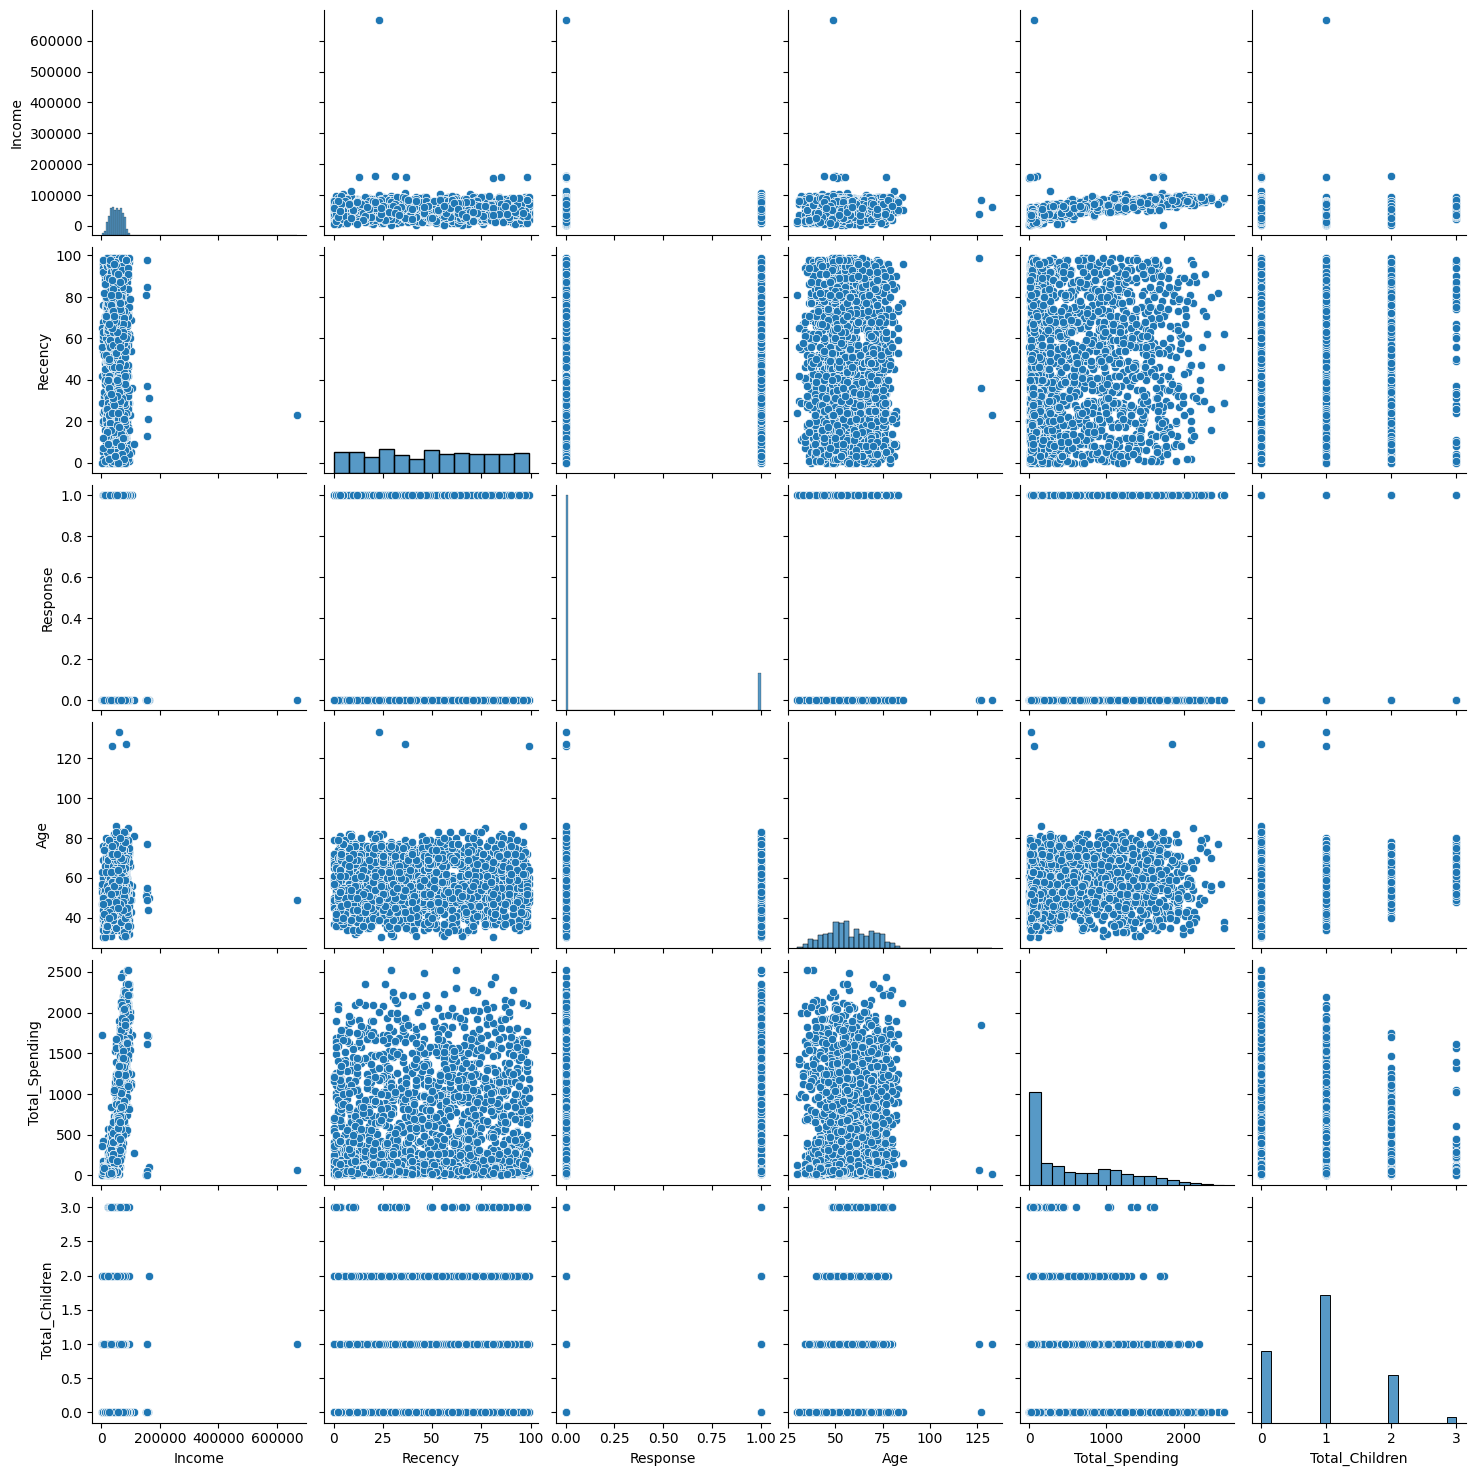

In [18]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# Relative plots fo some features - Pair Plots.
sns.pairplot(df_cleaned[cols])

# As we can see age has outlier(age 120) and income of (600k+)

<Axes: xlabel='Income', ylabel='Total_Spending'>

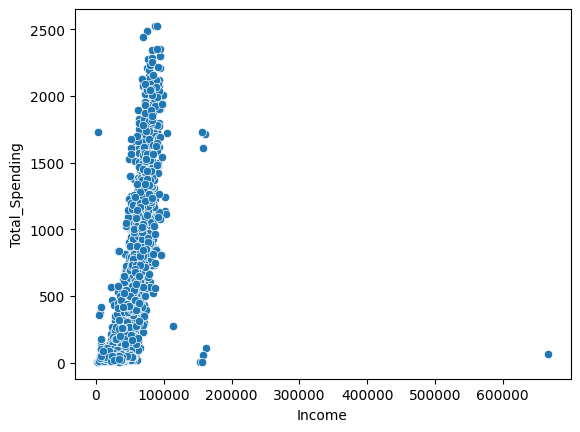

In [19]:
sns.scatterplot(x=df_cleaned["Income"], y=df_cleaned["Total_Spending"])

In [20]:
# Removing Outliers.
print("Data size with outliers: ", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000)]

print("Data size after removing outliers: ", len(df_cleaned))

Data size with outliers:  2240
Data size after removing outliers:  2236


## Heatmap

In [21]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

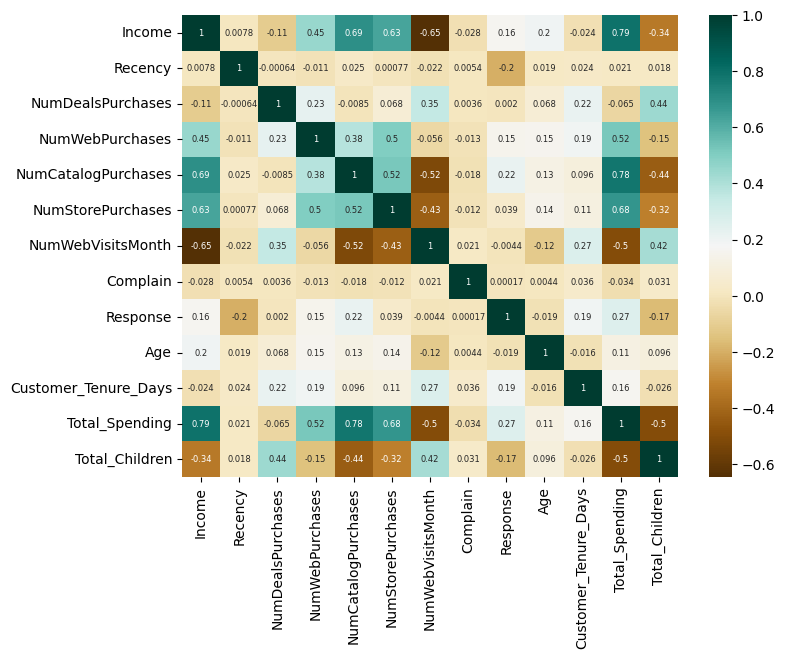

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="BrBG"
)

# Conclusive Data Points:
# 0.79 - Income - Total Spending
# 0.69 - Income - Catalog Product
# 0.63 - Income - Store Purchase
# -0.65 - Income - No of web visits
# 0.78 - Spending - Catalog Purchases
# 0.65 - Spending - Store Purchases

In [23]:
df_cleaned.head(5)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Feature Encoding

In [24]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [26]:
# Dont drop_first=True when u are clustering.
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [27]:
enc_df.head(5)

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [28]:
# concatination of df_clean + enc_df, and dropping cat_cols.
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [29]:
df_encoded.head(5)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


## Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
X = df_encoded

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# dataset is scaled and stored into X.

## Visualization

In [33]:
X_scaled.shape 

(2236, 18)

In [34]:
# 2D Visualization
from sklearn.decomposition import PCA

In [35]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [36]:
pca.explained_variance_ratio_
# ony (23 + 11+ 10)% of variance is being show, as we are compressing features from 18 to 3.

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

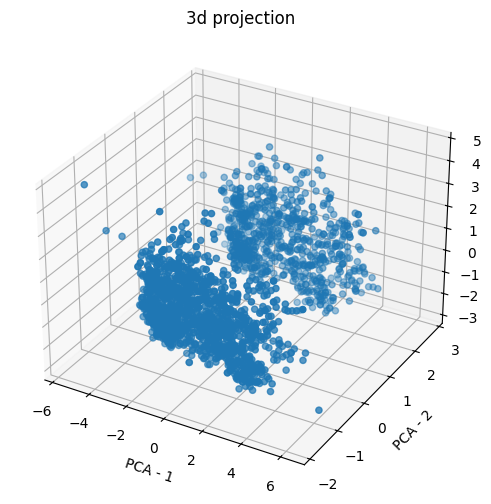

In [37]:
# plotting
fig = plt.figure(figsize=(10, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
)

ax.set_xlabel("PCA - 1")
ax.set_ylabel("PCA - 2")
ax.set_zlabel("PCA - 3")
ax.set_title("3d projection")

## Analyze K value

### 1. Elbow Method

In [38]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [39]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [40]:
print("best k is: ", optimal_k)

best k is:  4


Text(0, 0.5, 'WCSS')

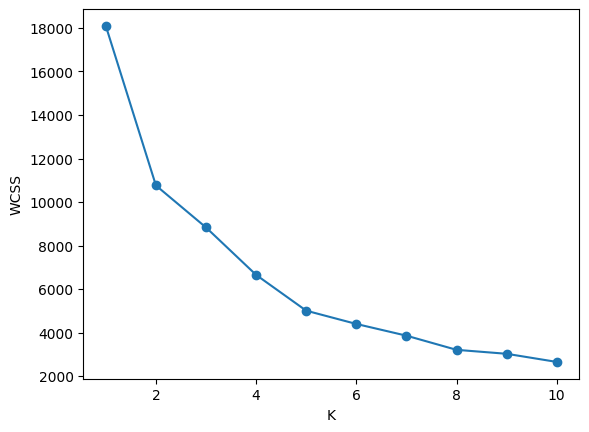

In [41]:
# plot
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

### 2. Silhouette Score

Text(0, 0.5, 'Silhouette Score')

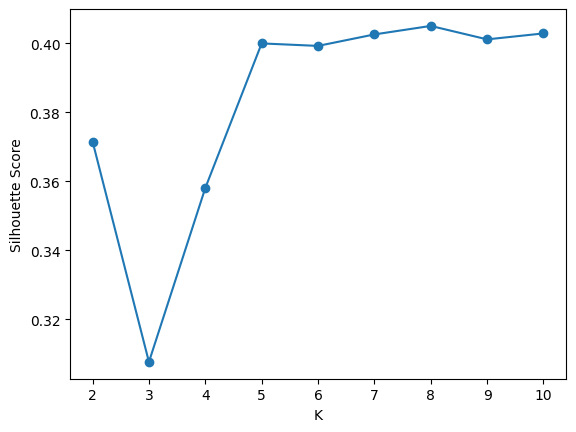

In [42]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")

Text(0, 0.5, 'SS')

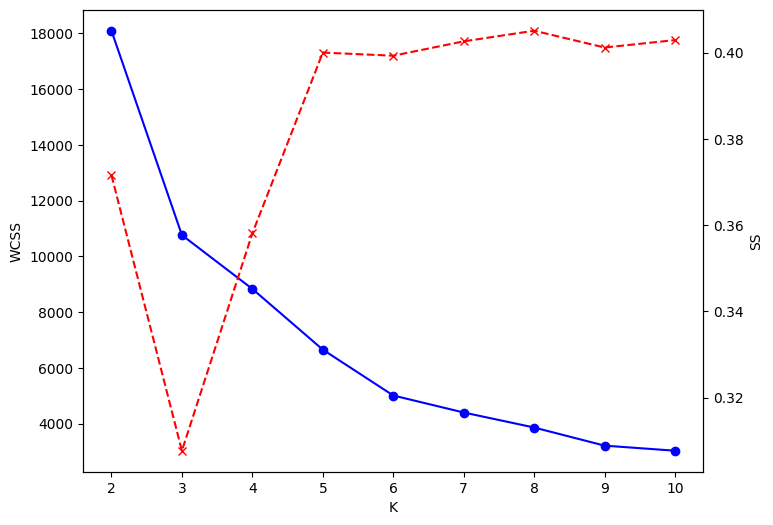

In [43]:
# Combined plot for better visuallisations

k_range = range(2, 11)
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# as we can see both of the lines intercept at k value = 4.

## Clustering

### 1. K-Means

In [44]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

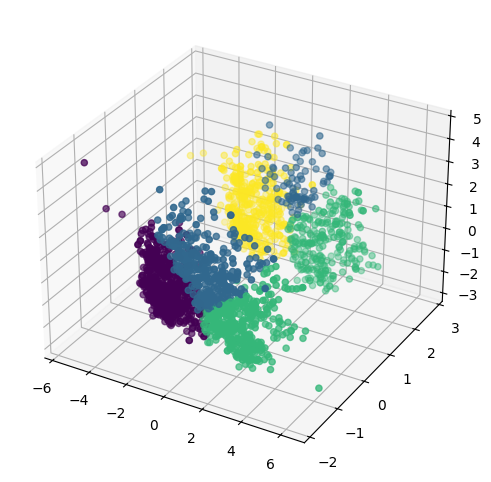

In [45]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

### 2. Agglomerative Cluster

In [46]:
from sklearn.cluster import AgglomerativeClustering

In [47]:
agg_cluster = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

labels_agg = agg_cluster.fit_predict(X_pca)

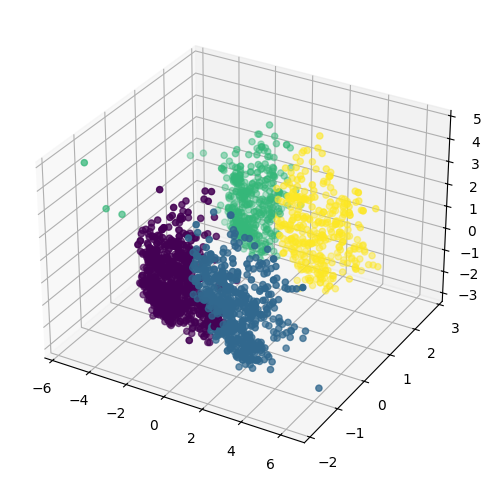

In [48]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)
# Visualising a better cluster than Kmeans.

## Characterizations of Clusters

In [49]:
X["cluster"] = labels_agg

In [50]:
X.head(5)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

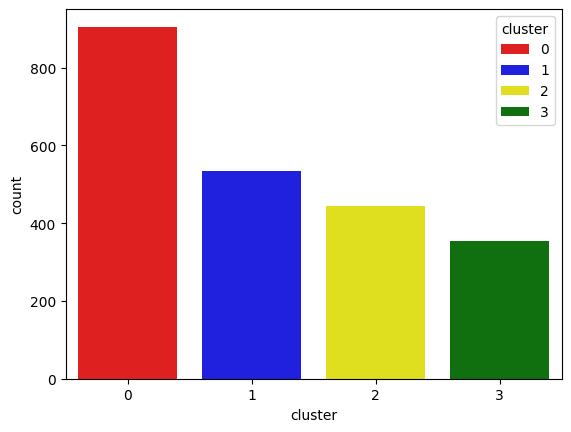

In [51]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

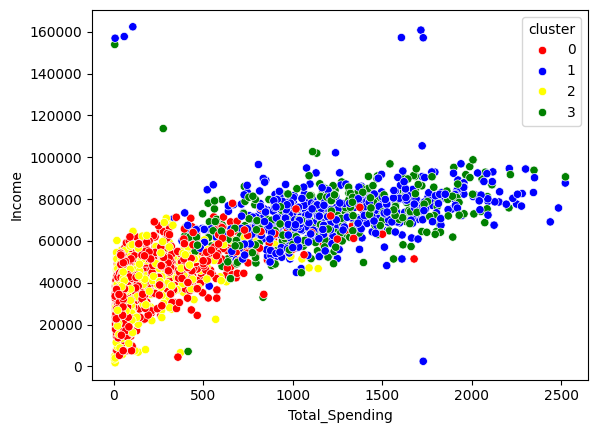

In [52]:
# Checking Income and Spending patterns.

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [53]:
# Cluster 0 [Red]
# Low / Moderate Income
# Low / Moderate Spending

# Cluster 1 [Blue]
# High income
# High Spending

# Cluster 2 [Yellow]
# Low Income
# Low Spending

# Cluster 3 [Green]
# Moderate / High Income
# High Spending

# Cluster 1 & 3 has the highest income
# Cluster 0 & 2 has low income and low spending

## Cluster summary

In [54]:
cluster_summary = X.groupby("cluster").mean()
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
cluster,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


In [55]:
cluster_summary.T

cluster,0,1,2,3
Income,39680.580110,72808.445693,36960.143018,70722.681303
Recency,48.914917,49.202247,48.319820,50.504249
NumDealsPurchases,2.594475,1.958801,2.594595,1.855524
NumWebPurchases,3.153591,5.687266,2.713964,5.790368
NumCatalogPurchases,0.969061,5.498127,0.837838,5.014164
NumStorePurchases,4.143646,8.659176,3.623874,8.430595
NumWebVisitsMonth,6.307182,3.580524,6.659910,3.728045
Complain,0.011050,0.005618,0.011261,0.005666
Response,0.076243,0.166667,0.141892,0.320113
Age,55.669613,59.492509,55.691441,58.932011


## Cluster Analysis & Business Insights

### Cluster 0 — Family Shoppers
- More children at home, has a partner
- Low response rate to campaigns
- High web visits but low web, catalog, and store purchases
- Deal-seeking behaviour (discounts & coupons)
- **Strategy:** Target with family deals and discount-based campaigns

### Cluster 1 — Loyalty Candidates
- Fewer children, slightly older, has a partner
- Average campaign response
- Low web purchases, high store and catalog purchases
- **Strategy:** Enroll in loyalty programs to increase retention 

### Cluster 2 — Digital Browsers
- More children, lives alone
- Average recency, high web visits
- High web, catalog, and store purchases
- Comfortable with discounts
- **Strategy:** Retarget through digital channels and sales promotions

### Cluster 3 — Premium Customers ⭐
- Fewer children, slightly older, lives alone
- **Best campaign response rate**
- Low web visits but high store and catalog purchases
- **Strategy:** Offer premium services and exclusive catalogs — best ROI segment

---

### Cluster Summary (by Income & Spend)
| Cluster | Income Level | Spending Level | Label |
|---------|-------------|----------------|-------|
| 0 (Red) | Low / Moderate | Low / Moderate | Family Shoppers |
| 1 (Blue) | High | High | Premium Loyalists |
| 2 (Yellow) | Low | Low | Passive Segment |
| 3 (Green) | Moderate | High | High-Value Singles |